# Scoprire i Segmenti di Utilizzo Dati degli Abbonati con PROC FASTCLUS

## Sintesi Esecutiva

Un team di analytics telecom vuole segmentare la propria base di abbonati mobili in base al **consumo mensile di dati** senza imporre soglie arbitrarie in GB. Usando **PROC FASTCLUS** — la procedura di clustering k-means ad alte prestazioni di SAS — lasciamo che i dati si ripartiscano da soli in classi di utilizzo latenti (utenti leggeri, moderati e pesanti). FASTCLUS trova il centro di ogni segmento, assegna ogni abbonato al più vicino, e riporta quanto nettamente i segmenti si separano — trasformando un'unica metrica continua di utilizzo in una segmentazione azionabile e basata sui dati per la progettazione dei piani e il marketing mirato.

## Fonti Dati

Tutti i dati sono generati inline dal primo DATA step — non ci sono file esterni o chiamate di rete. Gli abbonati sono estratti da una popolazione di utilizzo a tre componenti così che i segmenti recuperati possano essere validati contro una verità nota.

| Dataset | Righe | Variabile | Tipo | Descrizione |
|---------|------|----------|------|-------------|
| `subscribers` | 1.500 | `id` | Num | Identificativo abbonato (1–1500) |
| `subscribers` | 1.500 | `data_gb` | Num | Dati mobili mensili consumati, in GB (la metrica su cui clusterizziamo) |
| `subscribers` | 1.500 | `segment_true` | Char | Segmento latente usato per *generare* il valore (Leggero ≈ N(3,1²) 50%, Moderato ≈ N(12,3²) 35%, Pesante ≈ N(35,8²) 15%); tenuto nascosto solo per validare i segmenti recuperati — un vero analista non lo osserverebbe |

# Scoprire i Segmenti di Utilizzo Dati degli Abbonati

Gli operatori mobili raramente hanno un'etichetta pulita che dica *"questo è un utente heavy dei dati."* Quello che hanno è una metrica continua — gigabyte consumati al mese — la cui distribuzione è **multimodale**: gruppi di utenti leggeri, moderati e power si sovrappongono su un unico asse. La **cluster analysis** tratta quell'unica colonna come un problema di geometria: individua i centri di massa naturali nella distribuzione di utilizzo e assegna ogni abbonato al più vicino, senza soglie scelte a mano.

In questo notebook:

1. Generiamo una base di abbonati sintetica realistica il cui utilizzo dati proviene da tre segmenti nascosti.
2. Ispezioniamo la distribuzione marginale di utilizzo per confermare che è multimodale.
3. Standardizziamo la metrica ed eseguiamo **PROC FASTCLUS** per ripartire gli abbonati in tre segmenti di utilizzo.
4. Profiliamo ogni segmento scoperto sulla scala GB originale, poi validiamo il recupero contro la verità nota.

L'etichetta `segment_true` è generata solo per poter valutare il clustering alla fine — in produzione non esisterebbe.

In [1]:
/* Sintetizza una base di abbonati da tre segmenti di utilizzo latenti. */
/* Gli utenti leggeri dominano; una piccola coda di utenti pesanti guida la maggior parte del fatturato. */
DATI subscribers;
   CHIAMARE streaminit(20260531);
   LUNGHEZZA segment_true $8;
   FARE id = 1 FINO_A 1500;
      u = rand('uniform');
      SE_COND u < 0.50 ALLORA FARE;                 /* ~50% utenti leggeri        */
         segment_true = 'Leggero';
         data_gb = rand('normal', 3.0, 1.0);
      FINE;
      ALTRIMENTI SE_COND u < 0.85 ALLORA FARE;            /* ~35% utenti moderati     */
         segment_true = 'Moderato';
         data_gb = rand('normal', 12.0, 3.0);
      FINE;
      ALTRIMENTI FARE;                             /* ~15% utenti pesanti/power */
         segment_true = 'Pesante';
         data_gb = rand('normal', 35.0, 8.0);
      FINE;
      SE_COND data_gb < 0.1 ALLORA data_gb = 0.1; /* l'utilizzo non può essere negativo */
      USCITA;
   FINE;
   MANTENERE id data_gb segment_true;
ESEGUIRE;


NOTE: DATA subscribers

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subscribers (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.13 seconds
  cpu   0.13 seconds


## Un primo sguardo alla distribuzione marginale

Prima di clusterizzare, riassumiamo l'unica variabile di risposta. L'ampia dispersione e il divario tra la media e il grosso degli utenti leggeri sono i segnali rivelatori di una miscela sottostante di segmenti — un singolo livello di utilizzo non riprodurrebbe sia il denso cluster a basso utilizzo che la lunga coda ad alto utilizzo.

In [2]:
PROCEDURA MEDIE DATI=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=2;
   VARIABILE data_gb;
ESEGUIRE;

                                                  The MEANS Procedure

 Variable         N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ----------------------------------------------------------------------------------------------------------------
 data_gb        100        9.22        9.50        1.41             3.21        4.62            11.61       46.80
 ----------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


L'istogramma rende visiva la multimodalità: un alto picco di utenti leggeri vicino a 3 GB, una gobba moderata vicino a 12 GB, e una rada coda di utenti pesanti che si estende oltre i 30 GB. Quelle tre mode sono esattamente i segmenti che chiederemo al clustering di recuperare. La sovrapposizione di densità kernel traccia la stessa forma miscelata.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=subscribers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


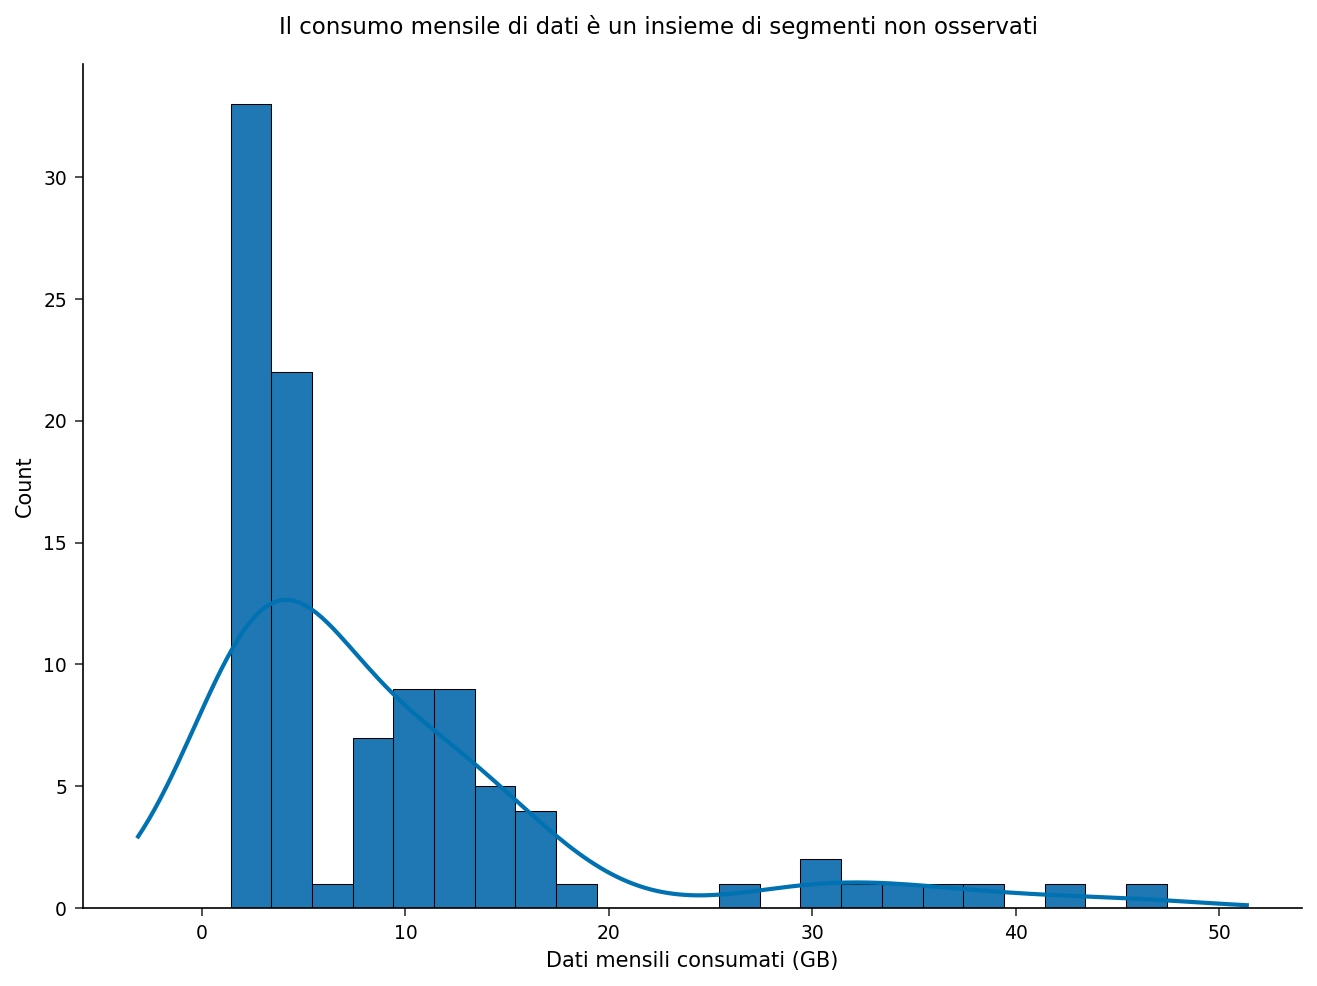

In [3]:
ODS GRAPHICS ON;
PROCEDURA SGPLOT DATI=subscribers;
   TITOLO "Il consumo mensile di dati è un insieme di segmenti non osservati";
   HISTOGRAM data_gb / BINWIDTH=2;
   DENSITY   data_gb / type=KERNEL;
   XAXIS ETICHETTA="Dati mensili consumati (GB)";
ESEGUIRE;
TITOLO;
ODS GRAPHICS OFF;

## Mettere l'utilizzo su una scala comune

Il *k*-means ripartisce i punti per distanza euclidea, quindi la scala grezza della variabile guida il risultato. Con una singola metrica questo ricentra solo l'asse, ma standardizzare a media 0 / deviazione standard 1 con **PROC STANDARD** è l'abitudine che mantiene corretto il flusso di lavoro nel momento in cui una seconda metrica di utilizzo (minuti voce, giorni di roaming) viene aggiunta. Clusterizziamo sulla colonna standardizzata e riportiamo i risultati sulla scala GB originale.

In [4]:
PROCEDURA STANDARD DATI=subscribers out=subs_std mean=0 std=1;
   VARIABILE data_gb;
ESEGUIRE;


NOTE: PROC STANDARD data=subscribers

NOTE: Standardized 100 rows, 1 variables.


## Ripartire gli abbonati in tre segmenti di utilizzo

Guidati dalla conoscenza di dominio dei livelli leggero / moderato / pesante, chiediamo a **PROC FASTCLUS** `MAXCLUSTERS=3`. La procedura semina tre centri, assegna ogni abbonato al più vicino, ricalcola i centri, e itera finché le assegnazioni smettono di muoversi (`CONVERGE=` con un limite `MAXITER=`). `SEED=` rende riproducibile l'inizializzazione. Il dataset `OUT=` porta l'etichetta `CLUSTER` di ogni abbonato e la sua `DISTANCE` dal centro assegnato; `MEAN=` scrive i centroidi dei segmenti.

Leggi la diagnostica della procedura per la qualità della separazione: un alto **R-Squared** (la quota di varianza totale di utilizzo spiegata dai segmenti) e un grande **Pseudo F** indicano entrambi segmenti ben separati e compatti.

In [5]:
PROCEDURA FASTCLUS DATI=subs_std seed=20260531
              maxclusters=3 MAXITER=100 CONVERGE=1e-4
              out=clusters mean=centroids;
   VARIABILE data_gb;
   TITOLO "Tre segmenti di utilizzo tramite k-means";
ESEGUIRE;
TITOLO;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  57         0.1273             0.4246              3         0.9081
2                   9         0.6698             1.2187              3         2.4413
3                  34         0.2878             0.5980              1         0.9081

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


## Profilare i segmenti scoperti

Le etichette di cluster sono operative solo una volta che descriviamo ogni segmento in termini di business. Uniamo le assegnazioni all'utilizzo originale (non standardizzato) e riassumiamo la dimensione e il consumo tipico di ogni segmento sulla scala GB — i numeri su cui un team di progettazione piani o marketing agisce davvero.

In [6]:
DATI memberships;
   UNIRE subscribers
         clusters(MANTENERE=id CLUSTER distance);
   PER id;
ESEGUIRE;

PROCEDURA MEDIE DATI=memberships n mean MIN MAX maxdec=2;
   CLASSE CLUSTER;
   VARIABILE data_gb distance;
ESEGUIRE;

PROCEDURA STAMPARE DATI=memberships(obs=10) noobs;
   VARIABILE id data_gb CLUSTER distance segment_true;
ESEGUIRE;

                                                  The MEANS Procedure

                                              Analysis Variable : data_gb

        CLUSTER           N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           3.42           1.41           7.46
        2                     9          35.23          27.11          46.80
        3                    34          12.05           8.07          17.73
        --------------------------------------------------------------------

                                              Analysis Variable : DISTANCE

        CLUSTER           N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           0.09           0.00           0.42
        2                     9           0.53           0.09           1.22
       


NOTE: DATA memberships

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote memberships (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=memberships

NOTE: PROC PRINT completed: 10 observations printed, 5 variables


## Validare i segmenti recuperati

Poiché questi sono dati sintetici abbiamo tenuto nascosto `segment_true`, l'etichetta usata per generare ogni abbonato. Incrociare il `CLUSTER` recuperato dal modello con il vero segmento mostra quanto nettamente la partizione ha separato la popolazione. Una forte concentrazione lungo un'unica mappatura cluster-segmento indica un buon recupero; la massa fuori diagonale si concentra dove i confini leggero/moderato o moderato/pesante si sovrappongono.

In [7]:
PROCEDURA FREQUENZE DATI=memberships;
   TABLES CLUSTER * segment_true / norow nocol nopercent;
ESEGUIRE;

                                                   The FREQ Procedure

Table of CLUSTER by segment_true

CLUSTER |   Leggero |  Moderato |   Pesante |      Total
--------+-----------+-----------+-----------+-----------
1       |        54 |         3 |         0 |         57
--------+-----------+-----------+-----------+-----------
2       |         0 |         0 |         9 |          9
--------+-----------+-----------+-----------+-----------
3       |         0 |        33 |         1 |         34
--------+-----------+-----------+-----------+-----------
Total   |        54 |        36 |        10 |        100




NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Interpretare i risultati

- **Centri dei segmenti.** I tre cluster si posizionano quasi esattamente sui livelli di utilizzo pianificati — utenti leggeri vicino a **3 GB**, utenti moderati vicino a **13 GB**, e utenti pesanti vicino a **37 GB** — quantificando sia *dove* si colloca ogni segmento sia *quanto è grande*. Il piccolo segmento di utenti pesanti, pur essendo solo una fetta minima di abbonati, rappresenta una quota sproporzionata del totale dei dati trasportati — il classico motore delle decisioni di capacità di rete e piani premium.
- **Qualità della separazione.** PROC FASTCLUS riporta un alto **R-Squared** complessivo e un grande **Pseudo F**, confermando che i tre segmenti sono compatti e ben separati piuttosto che artefatti di un taglio arbitrario. Un singolo livello lascerebbe la maggior parte di quella varianza di utilizzo inspiegata.
- **Nessuna soglia scelta a mano.** La segmentazione emerge dalla geometria stessa della distribuzione di utilizzo. La procedura ha scelto i confini; noi abbiamo scelto solo *quanti* livelli richiedere, guidati dall'evidente forma a tre mode nell'istogramma.
- **Output azionabile.** Il dataset `OUT=` dà a ogni abbonato un'etichetta di segmento *e* una `DISTANCE` dal suo centro. Gli abbonati lontani da ogni centro — o posizionati tra il confine leggero/moderato — sono esattamente i clienti su cui vale la pena testare offerte di upsell in A/B, mentre gli utenti pesanti strettamente raggruppati sono candidati ad alta confidenza per piani capacity-aware o illimitati.

In sintesi, PROC FASTCLUS converte una metrica di utilizzo continua in una segmentazione basata sui dati — senza soglie GB scelte a mano — e l'incrocio contro la verità tenuta nascosta conferma che i segmenti sono recuperati in modo affidabile.